In [1]:
import pandas as pd
import subprocess
from functools import reduce
import numpy as np
import umap
from plotnine import *
import os
import pickle
from itertools import product


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import simulations.genomes1000_sim as sim_functions

intermediate_file_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
root_dir = '/gpfs/commons/datasets/1000genomes'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'

In [3]:
# PARAMETERS
generate_sim = True
evaluate_sim = True
# generate all combinations of e and ps variables
ps_list = [True,False]
e_list = [0.5]
num_markers_assoc_list = [100,2000]
init_list = range(100) # 100 random initializations for each combination
bfile_path=f'{output_dir}/G'
af_df_filepath=admixture_filepath
# PARAMETERS

In [6]:
# ps=0.75
# e=0.5
# init=0
# num_clinical_assoc = 10
# extra_subgroups_size = 200
# M = 100
# num_markers_assoc=100
# sim_functions.sun_generate_sim_data(bfile_path, af_df_filepath,map_filepath,
#                           intermediate_file_dir,sim_functions.get_output_file_suffix(ps,e,init,num_markers_assoc),output_dir,
#                           sim_functions.get_output_file_suffix(ps,e,init,num_markers_assoc),
#                           ps,num_markers_assoc,e,extra_subgroups_size,M,num_clinical_assoc)

## Explore 1000 genomes data

Choose K=5 for admixture files; read in .ped and .map files

### Run GWAS with and without PCs and see how much genetic coefficients change 
At different levels of population stratification

make graph of GWAS

In [39]:
from itertools import product
import os, pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
from pyarrow.lib import ArrowInvalid


SIG = 5e-8
results_df = []

def counts_from_bool(true_arr, pred_arr):
    tp = np.count_nonzero(pred_arr & true_arr)
    tn = np.count_nonzero(~pred_arr & ~true_arr)
    fp = np.count_nonzero(pred_arr & ~true_arr)
    fn = np.count_nonzero(~pred_arr & true_arr)
    return tn, fp, fn, tp

for i, (ps, e, init, num_markers_assoc, phenotypic_subgroup) in tqdm(
    enumerate(product(ps_list, [0.50], init_list, num_markers_assoc_list, range(4)))
):
    output_file_suffix = sim_functions.get_output_file_suffix(ps, e, init, num_markers_assoc)
    meta_path = f"{output_dir}/simulation_metadata_{output_file_suffix}.pkl"

    with open(meta_path, "rb") as f:
        simulation_metadata = pickle.load(f)

    # read both covariate and no-covariate files once
    df_with = pd.read_parquet(
        f"{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}_Geno_Cov_True_results.parquet"    ).rename(columns={"OR": "OR_with_cov", "P": "P_with_cov"})
    if len(df_with['ERRCODE'].unique())>1:
        print(f"with {df_with[df_with['ERRCODE']!='.'].shape[0]}")
    df_with = df_with[(df_with['ERRCODE']=='.')&(df_with['ID']!='1:148754741')].copy() # badly behaved SNP, can remove with HWE filtering (check though)
    assert df_with[df_with['OR_with_cov']>150].shape[0]==0, f'unstable estimation for PHENOTYPE_FILE_Subgroup{phenotypic_subgroup}_{output_file_suffix}'

    df_nocv = pd.read_parquet(
        f"{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}_Geno_Cov_False_results.parquet"    ).rename(columns={"OR": "OR_no_cov", "P": "P_no_cov"})
    if df_nocv[(df_nocv['OR_no_cov']>150)&(df_nocv['ID']!='1:148754741')].shape[0]>0:
        print(df_nocv[df_nocv['OR_no_cov']>150][['ID','A1_FREQ','OR_no_cov']])
    if len(df_nocv['ERRCODE'].unique())>1:
        print(f"without {df_nocv[df_nocv['ERRCODE']!='.'].shape[0]}")
    df_nocv = df_nocv[(df_nocv['ERRCODE']=='.')&(df_nocv['ID']!='1:148754741')].copy() # badly behaved SNP, can remove with HWE filtering (check though)
    assert df_nocv[df_nocv['OR_no_cov']>150].shape[0]==0,f'unstable estimation for PHENOTYPE_FILE_Subgroup{phenotypic_subgroup}_{output_file_suffix}'


    wide = df_nocv.merge(df_with, on="ID", how="inner")
    if phenotypic_subgroup in range(2):
        associated_markers = set(simulation_metadata["markers_assoc"][phenotypic_subgroup])
    else:
        associated_markers = set()

    true_vec = wide["ID"].isin(associated_markers).to_numpy() # true associations

    pred_no = (wide["P_no_cov"].to_numpy() < SIG) # predicted associations no PCs
    pred_with = (wide["P_with_cov"].to_numpy() < SIG) # predicted associations with PCs

    tn0, fp0, fn0, tp0 = counts_from_bool(true_vec, pred_no) # tn, ... without PCs
    tn1, fp1, fn1, tp1 = counts_from_bool(true_vec, pred_with) # tn,... with PCs

    rel_change = ((wide["OR_with_cov"] - (wide["OR_no_cov"])) / wide["OR_no_cov"]).mean()

    results_df.append([
        ps, e, init, num_markers_assoc, phenotypic_subgroup,
        tn0, tn1,
        fp0, fp1,
        fn0, fn1,
        tp0, tp1,
        rel_change
    ])

results_df = pd.DataFrame(results_df, columns=[
    "ps", "e", "init", "num_markers_assoc", "phenotypic_subgroup",
    "tn_no_cov", "tn_with_cov",
    "fp_no_cov", "fp_with_cov",
    "fn_no_cov", "fn_with_cov",
    "tp_no_cov", "tp_with_cov",
    "mean_rel_change_OR_associated"
])


0it [00:00, ?it/s]

38it [00:05,  6.06it/s]

with 1


374it [00:57,  5.88it/s]

with 1


1600it [04:04,  6.54it/s]


In [40]:
results_df['mean_rel_change_OR_associated_percent'] = results_df['mean_rel_change_OR_associated']*100

Overall graphs

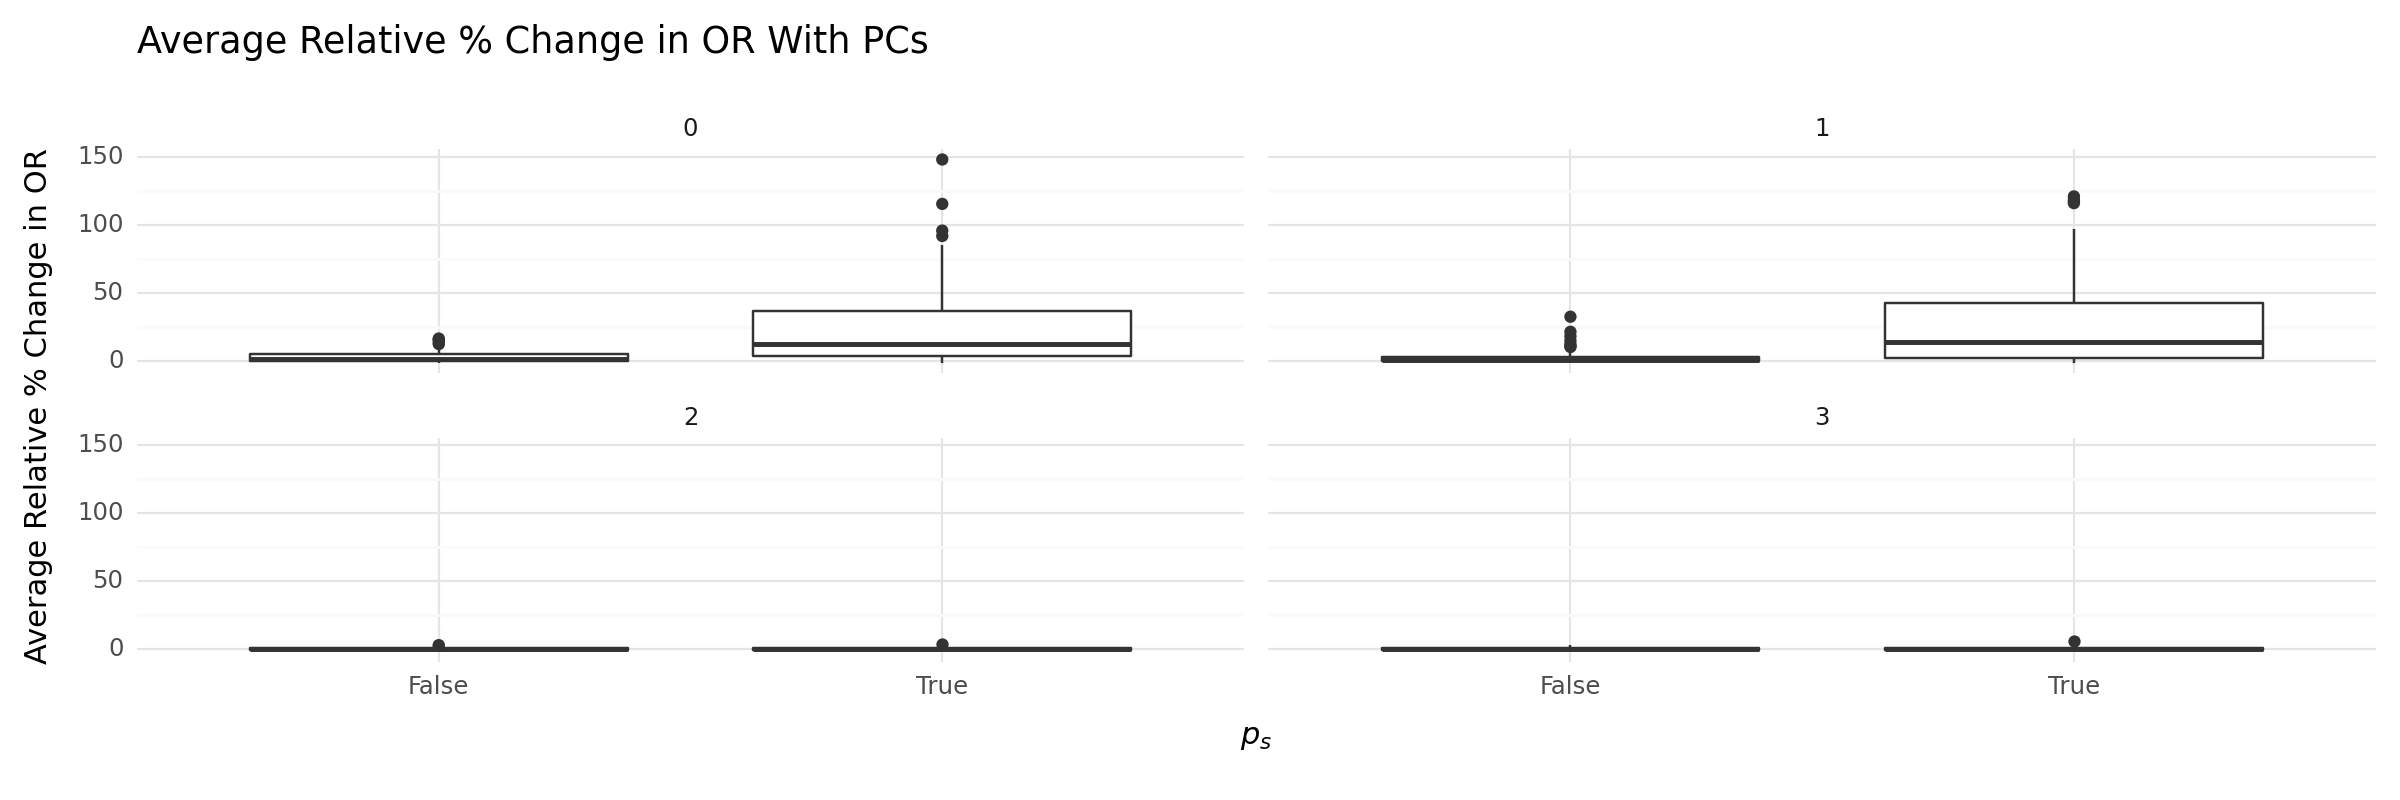

In [41]:
p = (ggplot(results_df[results_df['num_markers_assoc']==100], aes(x='ps', y='mean_rel_change_OR_associated_percent'))
     + geom_boxplot()
     + theme_minimal()
     + theme(figure_size=(12,4))
     + facet_wrap('~phenotypic_subgroup')
     + labs(title='Average Relative % Change in OR With PCs',y='Average Relative % Change in OR',x=r'$p_s$')) 
print(p)

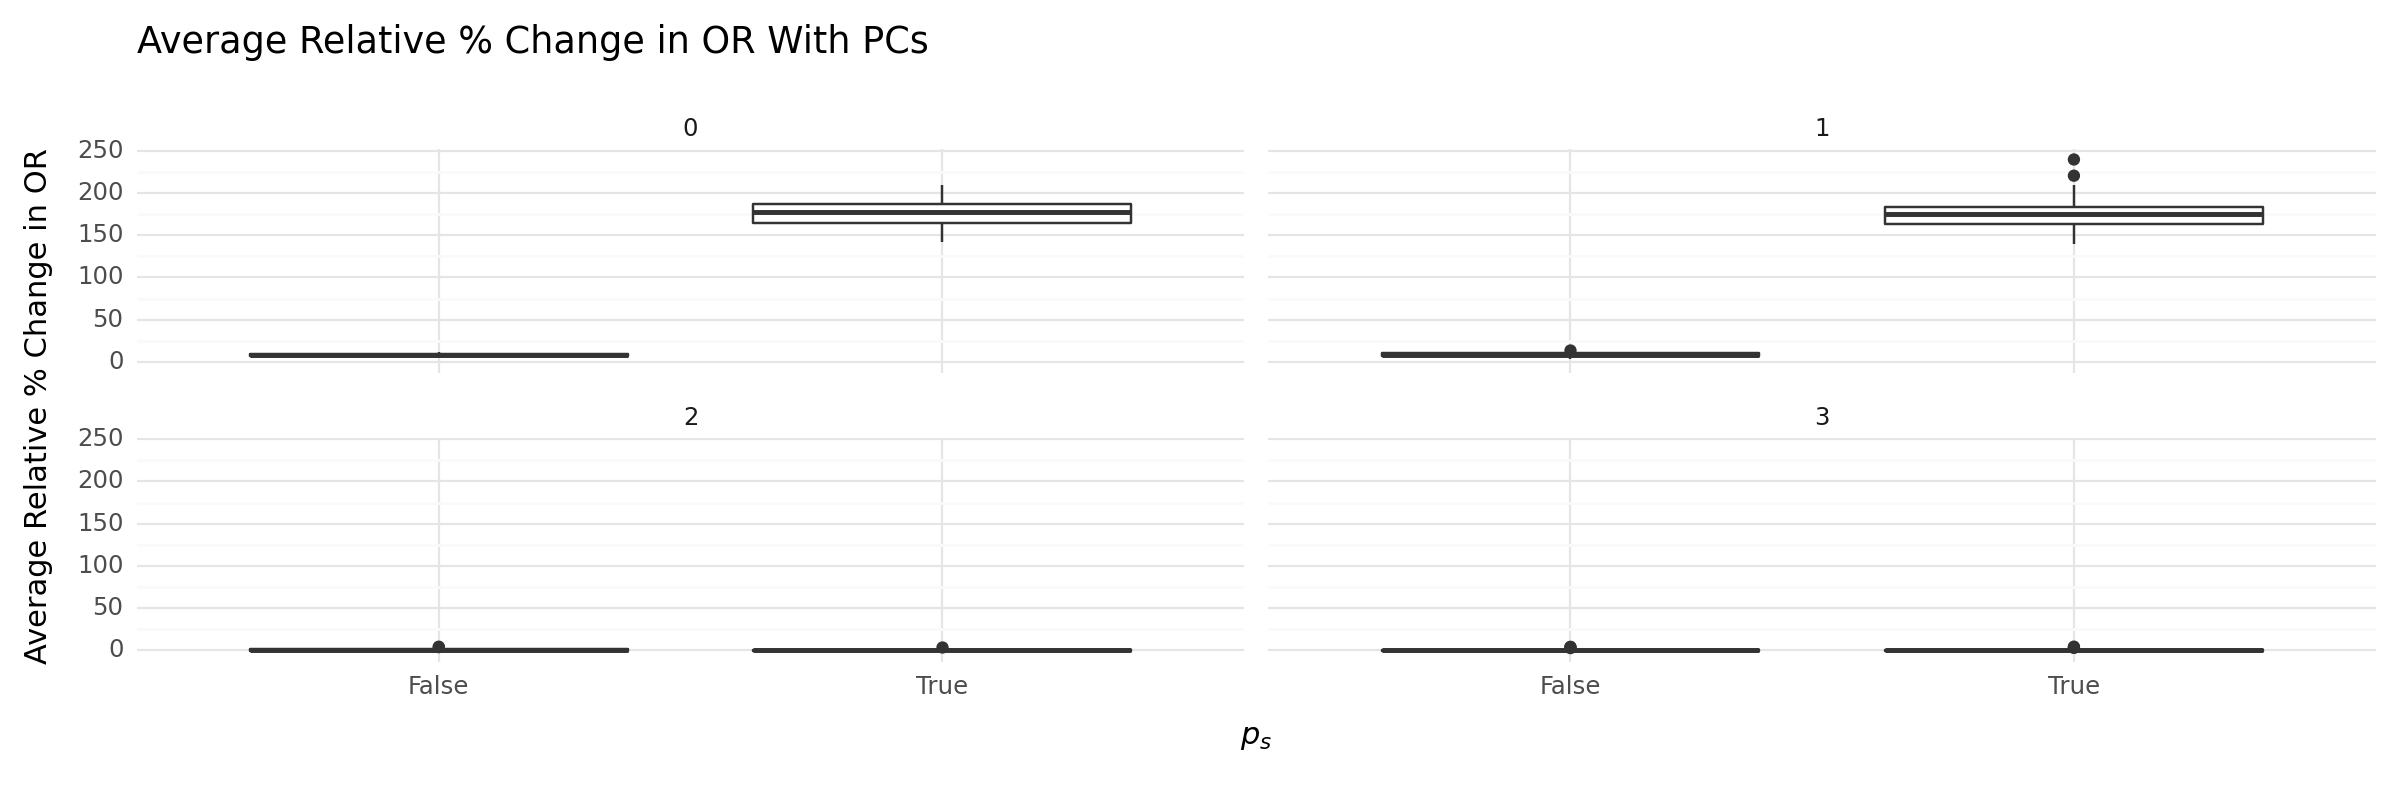

In [42]:
p = (ggplot(results_df[results_df['num_markers_assoc']==2000], aes(x='ps', y='mean_rel_change_OR_associated_percent'))
     + geom_boxplot()
     + theme_minimal()
     + theme(figure_size=(12,4))
     + facet_wrap('~phenotypic_subgroup')
     + labs(title='Average Relative % Change in OR With PCs',y='Average Relative % Change in OR',x=r'$p_s$')) 
print(p)

Graphs just for associated markers

In [11]:
results_df

,ps,e,init,num_markers_assoc,phenotypic_subgroup,tn_no_cov,tn_with_cov,fp_no_cov,fp_with_cov,fn_no_cov,fn_with_cov,tp_no_cov,tp_with_cov,mean_rel_change_OR_associated,mean_rel_change_OR_associated_percent
0,True,0.5,0,100,0,4482,9900,5418,0,13,100,87,0,0.321872,32.187227
1,True,0.5,0,100,1,6860,9900,3040,0,35,100,65,0,0.039593,3.959266
2,True,0.5,0,100,2,10000,10000,0,0,0,0,0,0,0.006302,0.630167
3,True,0.5,0,100,3,10000,10000,0,0,0,0,0,0,0.012167,1.216669
4,True,0.5,0,2000,0,3189,8000,4811,0,201,2000,1799,0,1.483233,148.323319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,False,0.5,4,100,3,10000,10000,0,0,0,0,0,0,-0.010567,-1.056726
76,False,0.5,4,2000,0,7696,8000,304,0,1994,2000,6,0,0.043075,4.307473
77,False,0.5,4,2000,1,7577,8000,423,0,1983,2000,17,0,0.050536,5.053636
78,False,0.5,4,2000,2,10000,10000,0,0,0,0,0,0,-0.008281,-0.828090


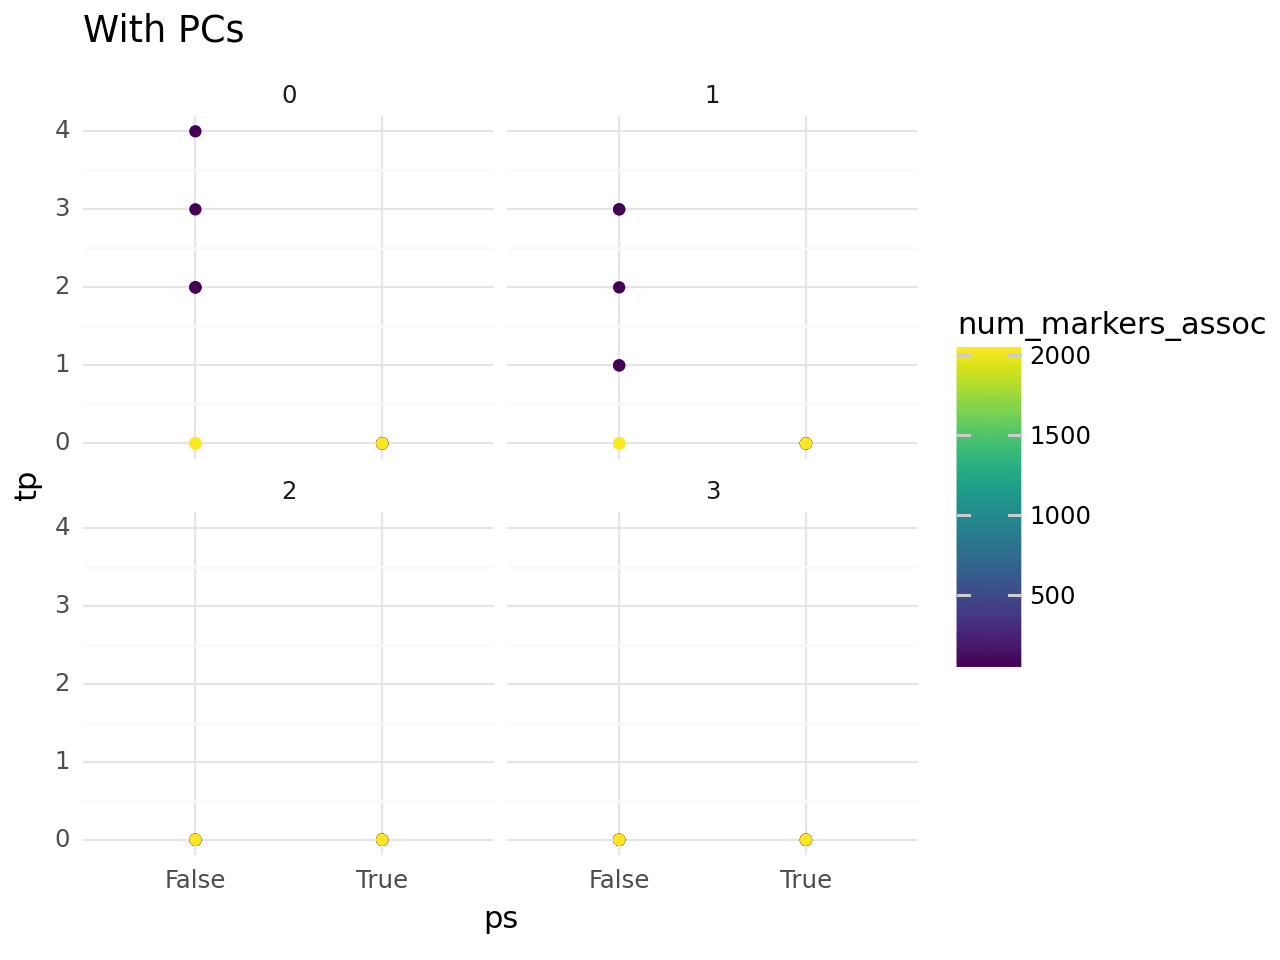

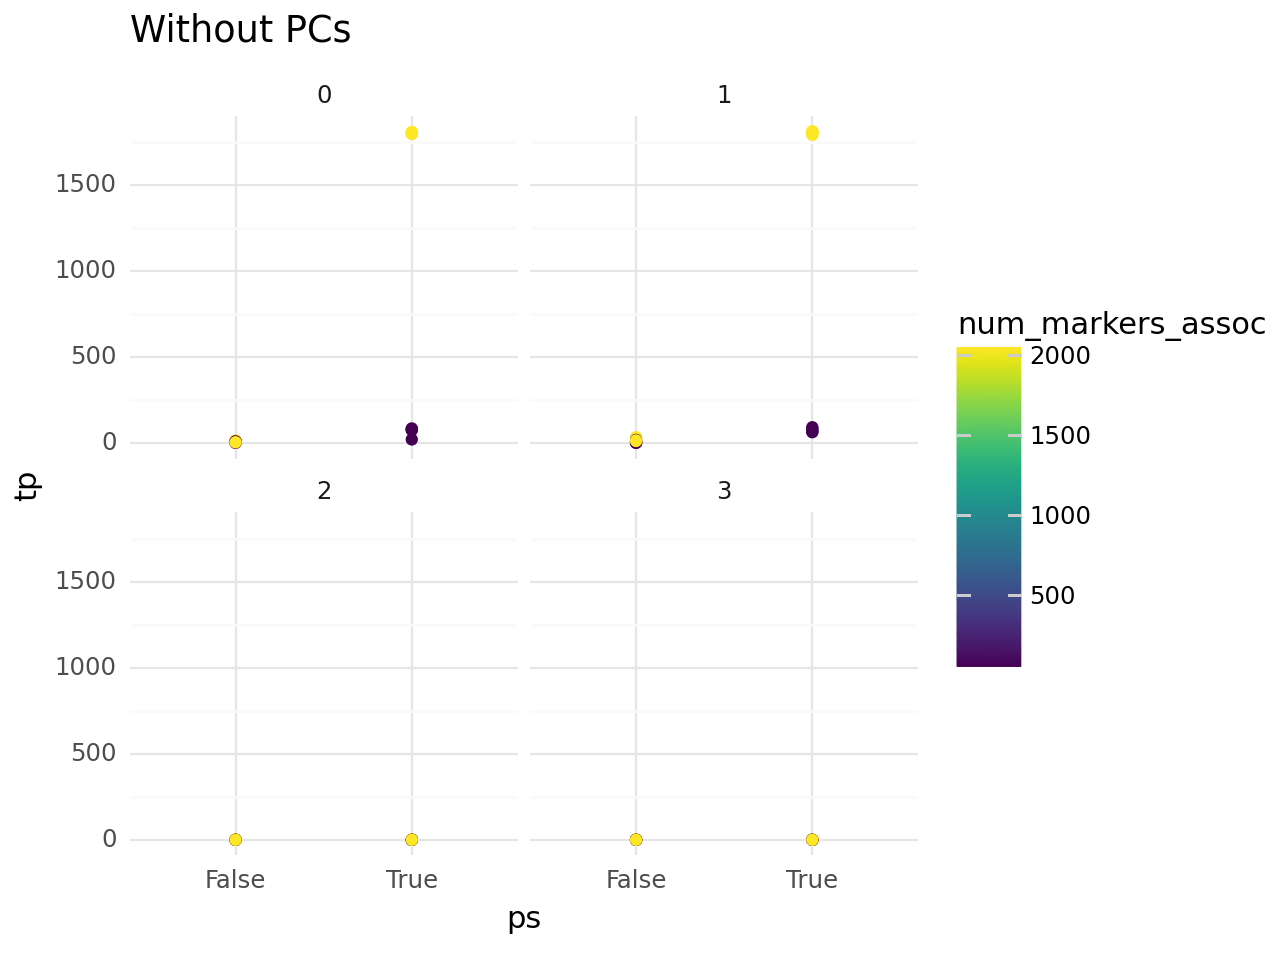

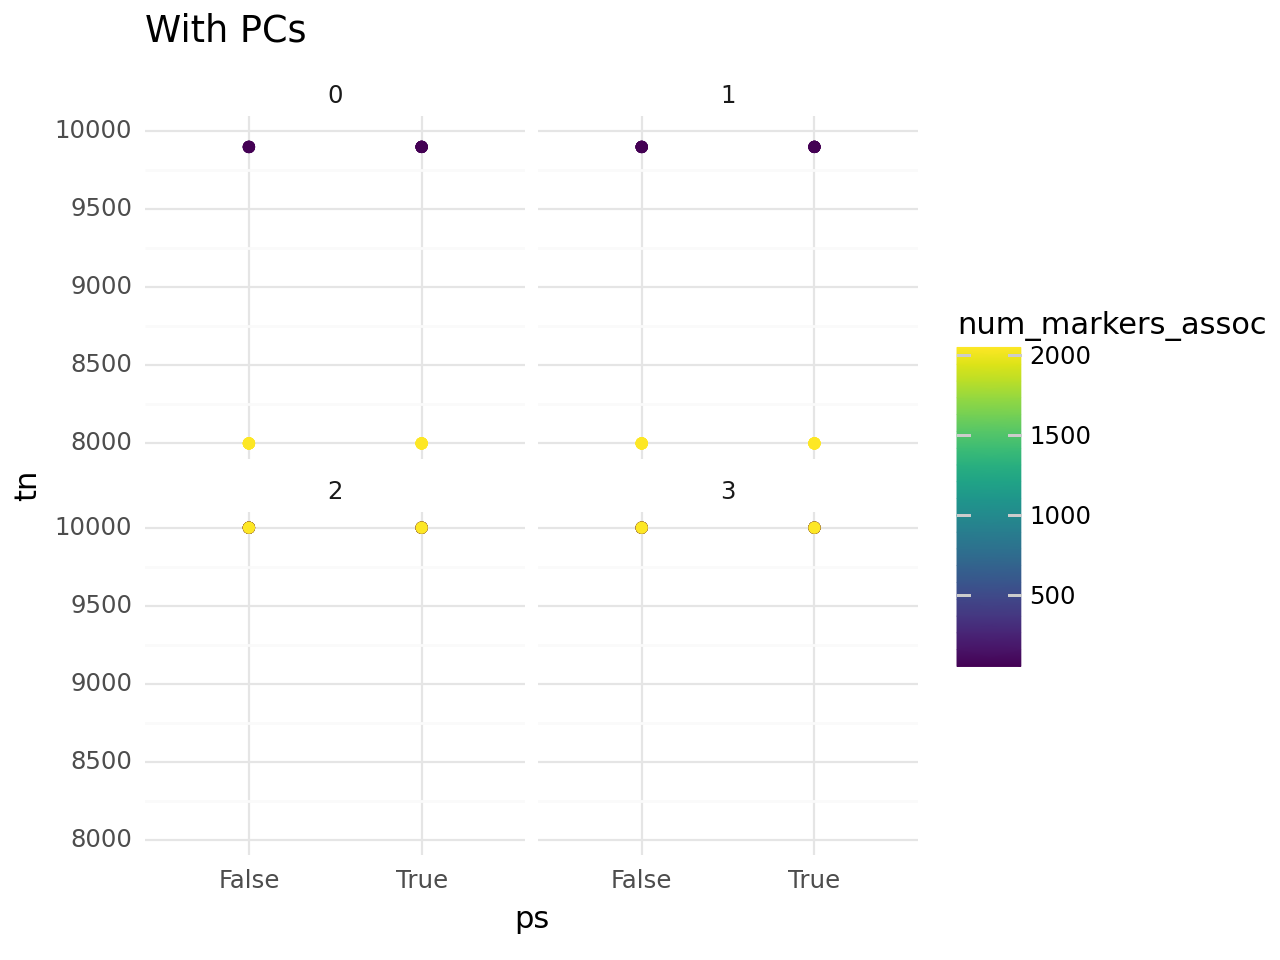

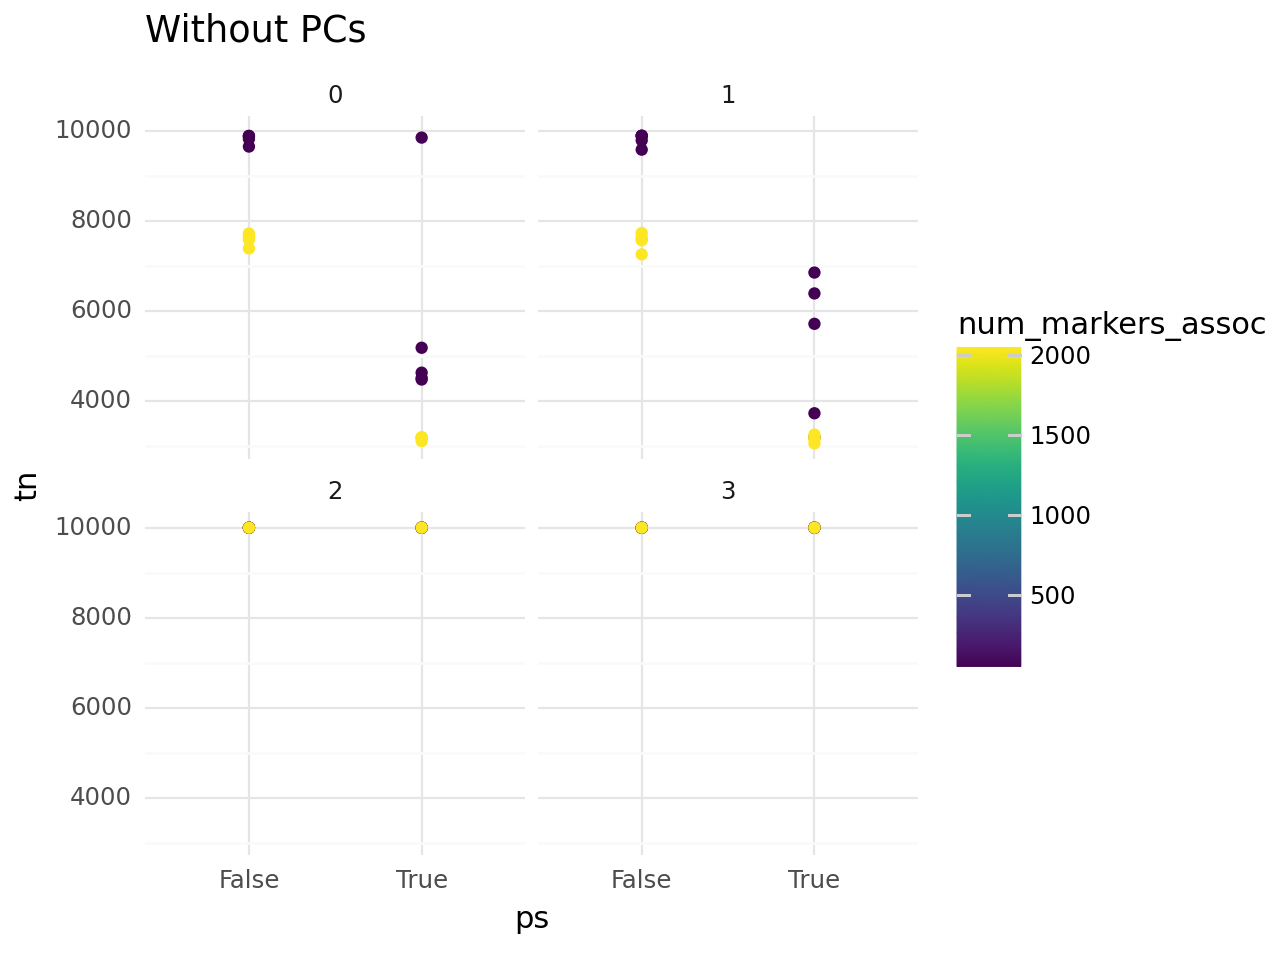

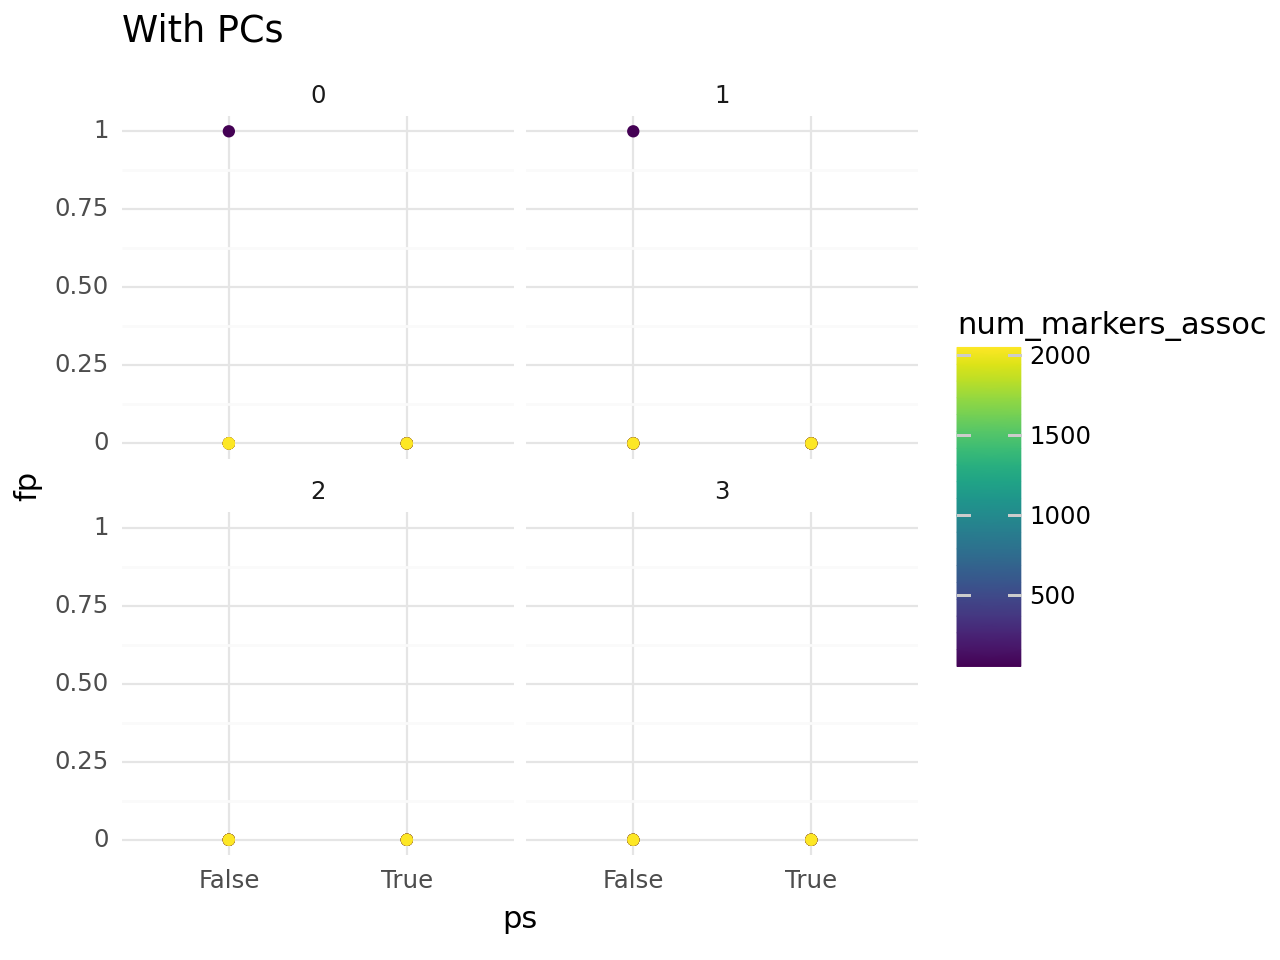

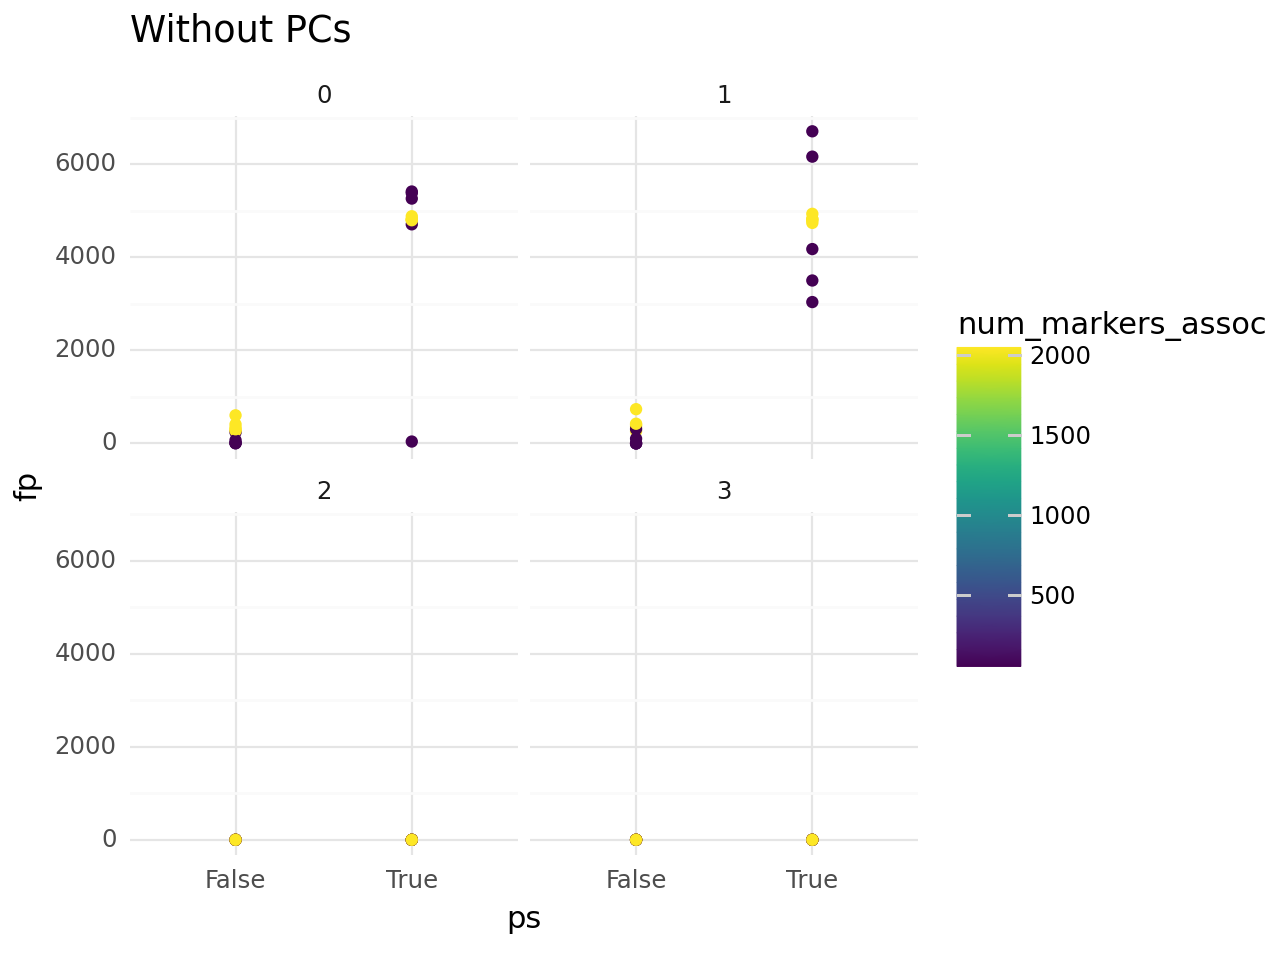

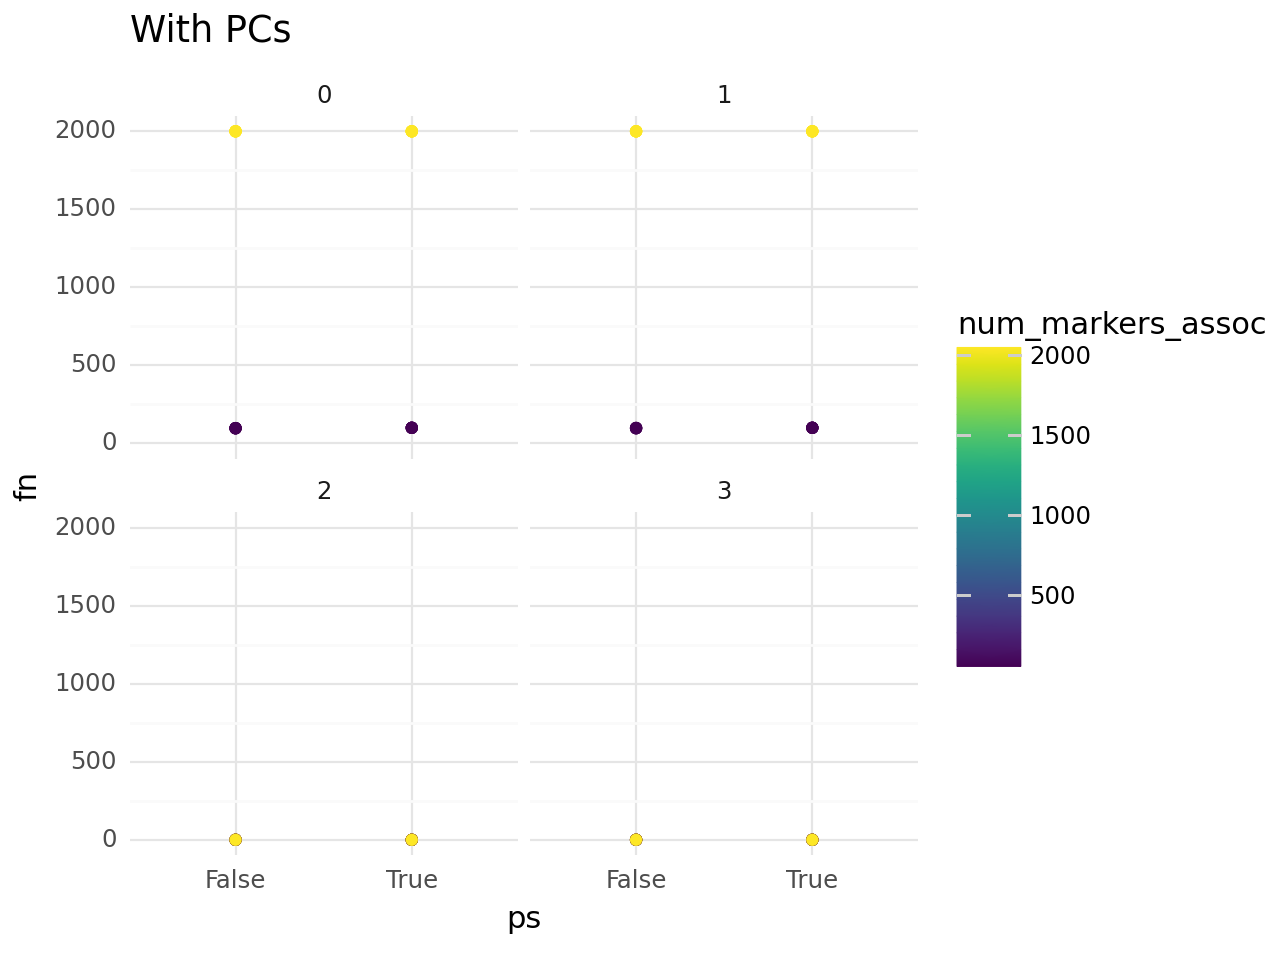

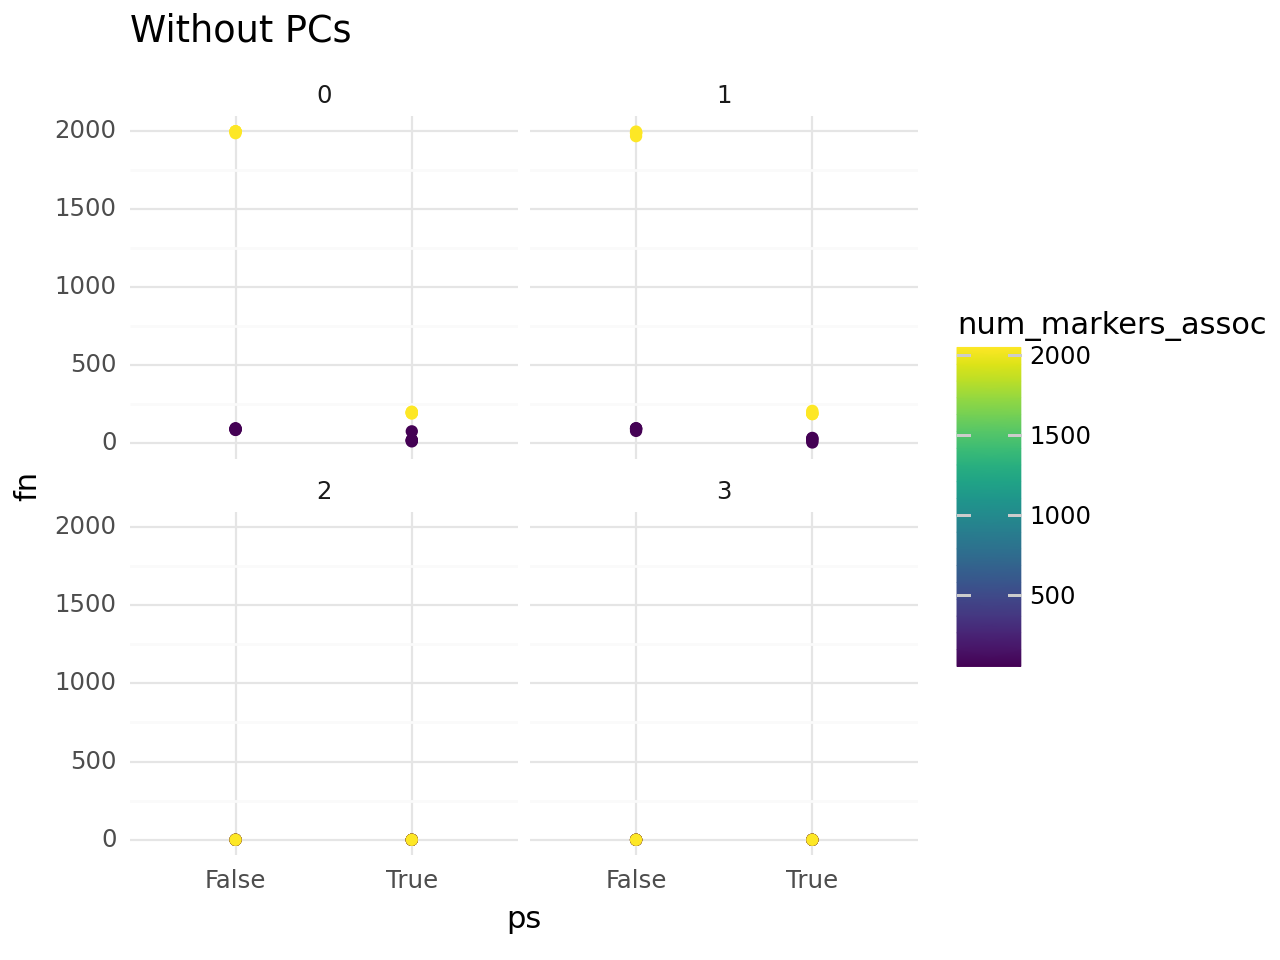

In [14]:
for metric in ['tp','tn','fp','fn']:
     for pcs in [True,False]:
          y_suffix = '_with_cov' if pcs else '_no_cov'
          title = 'With PCs' if pcs else 'Without PCs'
          p = (ggplot(results_df, aes(x='ps', y=f'{metric}{y_suffix}',fill='num_markers_assoc',color='num_markers_assoc'))
               + geom_point()
               + facet_wrap('~phenotypic_subgroup')
               + theme_minimal()
               + labs(title=title,y=metric.replace('_w_pcs',''))) 
          print(p)


In [5]:
for e in [0.5,1.0]:
     for af_variance_grouping in ['admixture','superpopulation']:
          for metric in ['accuracy','precision','recall']:
               title = f'e: {e}, AF variance grouping: {af_variance_grouping}'
               plot_df = results_df[(results_df['af_variance_grouping']==af_variance_grouping)&(results_df['e']==e)].melt(id_vars=["ps","e","phenotypic_subgroup"], value_vars=[f"{metric}_w_pcs", metric],
                         var_name="pcs_included", value_name="value").copy()
               plot_df['pcs_included'] = plot_df['pcs_included'].str.contains("w_pcs")

               p = (ggplot(plot_df, aes(x='ps', y=f'value',fill='pcs_included')) +
                    geom_bar(stat = "identity", position = "dodge") +
                    facet_wrap('~phenotypic_subgroup')
                    + theme_minimal()
                    + labs(title=title,y=metric,fill='PCs Included')) 
               print(p)


NameError: name 'results_df' is not defined

In [75]:
ps_list = np.round(np.arange(0, 1.0, 0.1),1)
e = 0.5
phenotypic_subgroup = 1
af_variance_grouping = 'admixture'
plot_df = []
plot_df_columns = ['ps','type','value']
for ps in ps_list:
    output_suffix = f'ps_{ps}_e_{e}_afgrouping_{af_variance_grouping}'
    with open(f"{output_dir}/simulation_metadata_{output_suffix}.pkl", "rb") as f:
        simulation_metadata = pickle.load(f)
    plink_results_w_wout_cov = []
    performance_metrics = {True:{},False:{}}
    plink_results = pd.read_csv(f'{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_suffix}_Geno_Cov_True.Phenotype.glm.logistic.hybrid',sep='\t')
    plink_results = plink_results[plink_results['TEST']=='ADD'].copy()

    plink_results['marker_assoc'] = plink_results['ID'].isin(simulation_metadata['markers_assoc'][phenotypic_subgroup])
    plot_df.append([ps,'tp',plink_results[(plink_results['P']<0.05)&(plink_results['marker_assoc']==True)].shape[0]])
    plot_df.append([ps,'fp',plink_results[(plink_results['P']<0.05)&(plink_results['marker_assoc']==False)].shape[0]])
plot_df = pd.DataFrame(plot_df,columns=plot_df_columns)

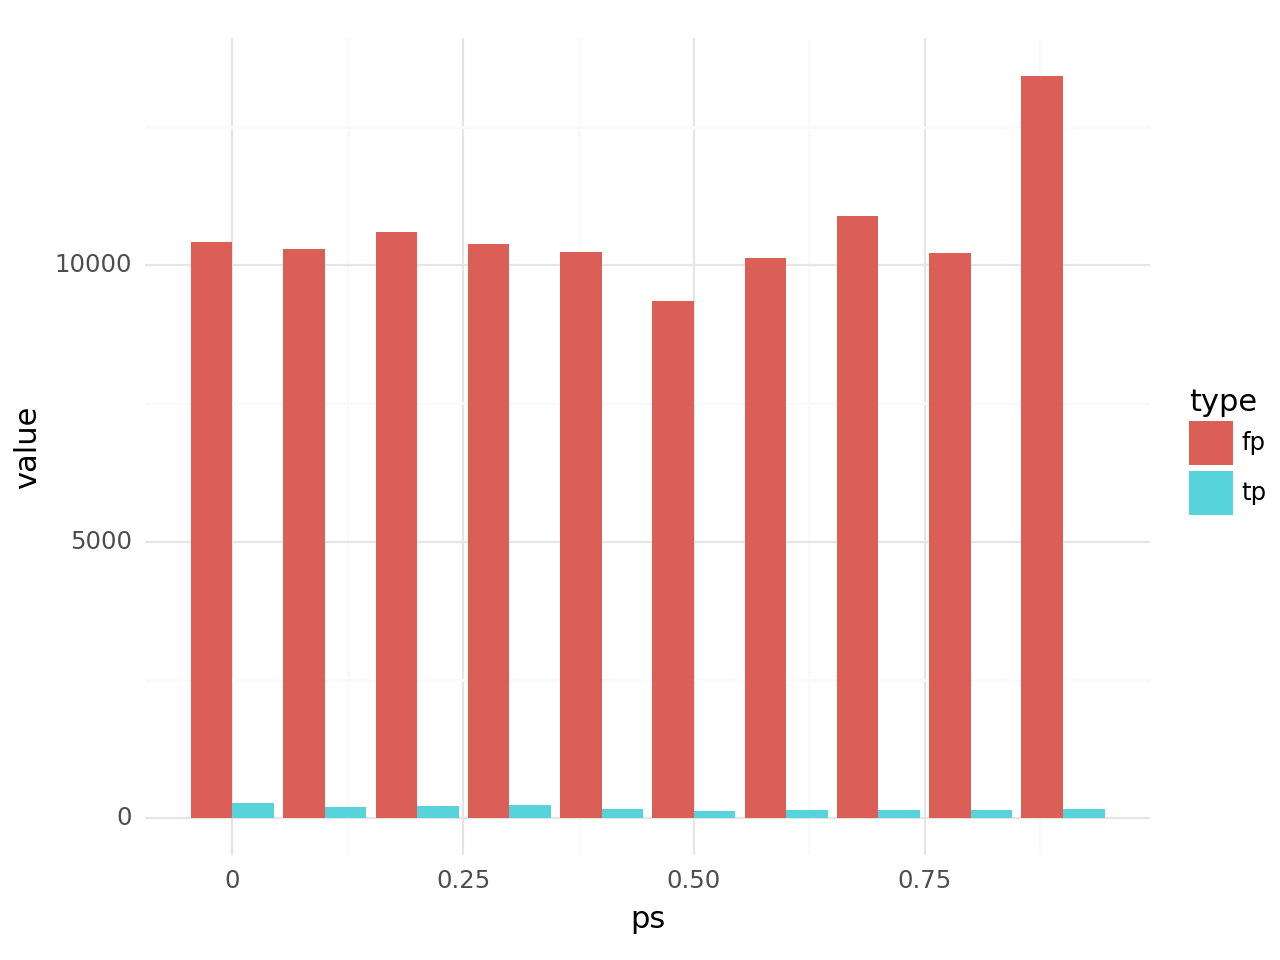

<Figure Size: (640 x 480)>

In [77]:
(
    ggplot(plot_df, aes(x='ps', y='value', fill='type'))
    + theme_minimal()
    + geom_bar(position='dodge',stat='identity')  # or position=position_dodge(width=0.8)
)

### Run GWAS at different levels of e and see how strength of association changes

In [90]:
# NOTE: TEST THAT COULD USE
assert all(bim_df['SNP'].values == map_df['ID'].values)

### Algorithm creation

In [6]:
root_dir = '/gpfs/commons/datasets/1000genomes'
import simulations.genomes1000_sim as sim_functions


In [6]:
# empirically, show monotone decrease of loss and stabilization over iterations
# show stability of parameter norms (U^t-U^(t-1))

# JointMF
import algorithms.JointMF as JointMF
import algorithms.JointMF_AAO as JointMF_AAO
import importlib
importlib.reload(JointMF)

writer = None

# read in simulated clinical data
ps = 0.75
e = 0.5
init = 0
num_markers_assoc = 2000
output_suffix = f'ps_{ps}_e_{e}_init_{init}_markersassoc_{num_markers_assoc}'
C = np.load(f'{output_dir}/C_{output_suffix}.npy')
with open(f"{output_dir}/simulation_metadata_{output_suffix}.pkl", "rb") as f:
    simulation_metadata = pickle.load(f)

# read in admixture fractions, sex and G
igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath, bfile_path=f'{output_dir}/G')
igsr_samples['Sex'] = igsr_samples['Sex'].map({'female': 0, 'male': 1})

admixture = pd.read_csv(f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5.Q',sep='\s+',header=None)
fam_df = pd.read_csv(f'{output_dir}/G.fam',sep='\s+',header=None)
fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
admixture['IID'] = fam_df['IID'].values
Z_df = admixture.merge(igsr_samples[['IID','Sex']], on='IID',how='inner')
Z = Z_df[[i for i in Z_df.columns if i!='IID']].to_numpy()

G = np.loadtxt(f'{output_dir}/G.raw',  usecols=range(6, 193634+6), dtype=np.int8, skiprows=1)
G = (G>0).astype(np.int8)


ML Flow practice

In [10]:
import mlflow
from mlflow import MlflowClient
from mlflow.models import infer_signature

import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


host="127.0.0.1"
port="8080"
# mlflow.set_tracking_uri(uri=f"http://{host}:{port}")
# mlflow.set_experiment("MLflow Quickstart")

client = MlflowClient(tracking_uri=f"http://{host}:{port}")
exp_name = "MLflow Quickstart2"
exp_id = client.create_experiment(
    exp_name,
    artifact_location="file:/abs/path/per_experiment_artifacts"  
)
mlflow.set_experiment(exp_name)

# Load the Iris dataset
X, y = datasets.load_iris(return_X_y=True)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters
params = {
    "solver": "lbfgs",
    "max_iter": 1000,
    "multi_class": "auto",
    "random_state": 8888,
}

# Train the model
lr = LogisticRegression(**params)
lr.fit(X_train, y_train)

# Predict on the test set
y_pred = lr.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)

with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("accuracy", accuracy)

    # Infer the model signature
    signature = infer_signature(X_train, lr.predict(X_train))

    # # Log the model, which inherits the parameters and metric
    # model_info = mlflow.sklearn.log_model(
    #     sk_model=lr,
    #     name="iris_model",
    #     signature=signature,
    #     input_example=X_train,
    #     registered_model_name="tracking-quickstart",
    # )

    # # Set a tag that we can use to remind ourselves what this model was for
    # mlflow.set_logged_model_tags(
    #     model_info.model_id, {"Training Info": "Basic LR model for iris data"}
    # )

🏃 View run sincere-shoat-49 at: http://127.0.0.1:8080/#/experiments/953306339708230954/runs/0be7ce6cbfe642e7ae199587d2a4b1b4
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/953306339708230954


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.


Force alternating optimization

In [4]:
def mats2vec(mats):
    """ Converts matrices back to vector form."""
    return np.concatenate([mat.flatten(order='F') for mat in mats])

def vec2mats(v, shapes): 
    """ Converts a vector into matrices based on given shapes.
    shapes is list of tuples defining shapes of each matrix to be formed
    """
    place_sum = 0
    mats = []
    for dim in shapes:
        size = dim[0]*dim[1]
        mats.append(v[place_sum:place_sum+size].reshape(dim[0], dim[1], order='F'))
        place_sum += size
    return mats

In [5]:
from scipy.special import gammaln

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

In [24]:
def total_loss(G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # define nec. elements
    G_hat = sigmoid(W@H_G.T + Z@U_G.T)
    # clipping for log purposes
    G_hat = np.clip(G_hat, 1e-7, 1 - 1e-7)
    C_hat = W@H_C.T + Z@U_C.T
    # clipping for log purposes
    C_hat = np.clip(C_hat, 1e-7, 1 - 1e-7)

    E_g = np.ones(G.shape)

    # define loss
    bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
    kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat + gammaln(C + 1)) # log(C!) can help stabilize
    regularization = lambda_W/2* np.trace(W.T @ W) +  lambda_H_G/2* np.trace(H_G.T @ H_G) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    if kl_div_loss < 0:
        assert True == False, "KL divergence loss negative"
    if bce_loss < 0:
        assert True == False, "BCE loss negative"
    f = bce_loss + kl_div_loss + regularization 
    return f

# Per-block factories (compute precomputes once per inner solve)

def make_fg_W(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of W
    U1 = Z@U_G.T
    U2 = Z@U_C.T
    C_const = np.sum(gammaln(C + 1))
    E_g = np.ones(G.shape)
    E_c = np.ones(C.shape)
    reg = lambda_H_G/2* np.trace(H_G.T @ H_G) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    def fun(x):
        W = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(W@H_G.T + U1), 1e-7, 1 - 1e-7)
        # clipping for log purposes
        C_hat = np.clip(W@H_C.T + U2, 1e-7, 1 - 1e-7)
        bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
        kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat) + C_const # log(C!) can help stabilize
        f = bce_loss + kl_div_loss + lambda_W/2* np.trace(W.T @ W) + reg 
        return f
    def jac(x):
        W = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(W@H_G.T + U1), 1e-7, 1 - 1e-7)
        # clipping for log purposes
        C_hat = np.clip(W@H_C.T + U2, 1e-7, 1 - 1e-7)

        G_tilde = np.divide(G,G_hat)
        G_bar = np.divide(E_g-G,E_g-G_hat)
        C_tilde = np.divide(C,C_hat)

        GW = (np.multiply(np.multiply(-G_tilde + G_bar,G_hat),E_g - G_hat)@H_G 
                + (E_c - C_tilde)@H_C + lambda_W*W)
        return GW.flatten(order='F')
    return fun, jac

def make_fg_HG(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of H_G
    U1 = Z@U_G.T
    C_hat = np.clip(W@H_C.T + Z@U_C.T, 1e-7, 1 - 1e-7)
    kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat + gammaln(C + 1)) # log(C!) can help stabilize
    E_g = np.ones(G.shape)
    reg = lambda_W/2* np.trace(W.T @ W) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    def fun(x):
        H_G = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(W@H_G.T + U1), 1e-7, 1 - 1e-7)
        bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
        f = bce_loss + kl_div_loss + reg +  lambda_H_G/2* np.trace(H_G.T @ H_G)
        return f
    def jac(x):
        H_G = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(W@H_G.T + U1), 1e-7, 1 - 1e-7)

        G_tilde = np.divide(G,G_hat)
        G_bar = np.divide(E_g-G,E_g-G_hat)

        GH_G = (W.T@np.multiply(np.multiply(-G_tilde + G_bar,G_hat),E_g - G_hat)).T + lambda_H_G*H_G
        return GH_G.flatten(order='F')
    return fun, jac

def make_fg_HC(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of H_C
    U1 = Z@U_C.T
    E_c = np.ones(C.shape)
    C_const = np.sum(gammaln(C + 1))
    G_hat = np.clip(sigmoid(W@H_G.T + Z@U_G.T), 1e-7, 1 - 1e-7)
    E_g = np.ones(G.shape)
    bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
    reg = lambda_W/2* np.trace(W.T @ W) +  lambda_H_G/2* np.trace(H_G.T @ H_G)
    def fun(x):
        H_C = x.reshape(shape, order='F')
        C_hat = np.clip(W@H_C.T + U1, 1e-7, 1 - 1e-7)
        kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat) + C_const # log(C!) can help stabilize
        f = bce_loss + kl_div_loss + reg +  lambda_H_C/2* np.trace(H_C.T @ H_C)
        return f
    def jac(x):
        H_C = x.reshape(shape, order='F')
        C_hat = np.clip(W@H_C.T + U1, 1e-7, 1 - 1e-7)

        C_tilde = np.divide(C,C_hat)

        GH_C = (W.T@(E_c - C_tilde)).T + lambda_H_C*H_C
        return GH_C.flatten(order='F')
    return fun, jac

def make_fg_UG(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of U_G
    U1 = W@H_G.T
    C_hat = np.clip(W@H_C.T + Z@U_C.T, 1e-7, 1 - 1e-7)
    kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat + gammaln(C + 1)) # log(C!) can help stabilize
    E_g = np.ones(G.shape)
    regularization = lambda_W/2* np.trace(W.T @ W) +  lambda_H_G/2* np.trace(H_G.T @ H_G) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    def fun(x):
        U_G = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(U1 + Z@U_G.T), 1e-7, 1 - 1e-7)
        bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
        f = bce_loss + kl_div_loss + regularization
        return f
    def jac(x):
        U_G = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(U1 + Z@U_G.T), 1e-7, 1 - 1e-7)

        G_tilde = np.divide(G,G_hat)
        G_bar = np.divide(E_g-G,E_g-G_hat)

        GU_G = (Z.T@(np.multiply(np.multiply(-G_tilde + G_bar,G_hat),E_g - G_hat))).T
        return GU_G.flatten(order='F')
    return fun, jac

def make_fg_UC(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of U_C
    U1 = W@H_C.T
    E_c = np.ones(C.shape)
    C_const = np.sum(gammaln(C + 1))
    G_hat = np.clip(sigmoid(W@H_G.T + Z@U_G.T), 1e-7, 1 - 1e-7)
    E_g = np.ones(G.shape)
    bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
    regularization = lambda_W/2* np.trace(W.T @ W) +  lambda_H_G/2* np.trace(H_G.T @ H_G) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    def fun(x):
        U_C = x.reshape(shape, order='F')
        C_hat = np.clip(U1 + Z@U_C.T, 1e-7, 1 - 1e-7)
        kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat) + C_const
        f = bce_loss + kl_div_loss + regularization
        return f
    def jac(x):
        U_C = x.reshape(shape, order='F')
        C_hat = np.clip(U1 + Z@U_C.T, 1e-7, 1 - 1e-7)

        C_tilde = np.divide(C,C_hat)

        GU_C = (Z.T@(E_c - C_tilde)).T
        return GU_C.flatten(order='F')
    return fun, jac

In [30]:
import numpy as np
from scipy.optimize import minimize

def alternating_opt(
    G,C,Z,              # true matrices
    W, H_G, H_C, U_G, U_C,  # initializations
    lambda_W, lambda_H_G, lambda_H_C,                   # regularization parameters
    method,                 # method and options for scipy minimize
    options,
    max_outer=30,
    tol=1e-4,
    nonneg=True             # set per-block L-BFGS-B bounds to [0, +inf)
):
    def one_block_update(name, X, method, options):
        x0 = X.flatten(order='F') 
        bnds = [(0, None)] * x0.size if nonneg else None

        if name == "W":
            fun, jac = make_fg_W(W.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        elif name == "H_G":
            fun, jac = make_fg_HG(H_G.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        elif name == "H_C":
            fun, jac = make_fg_HC(H_C.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        elif name == "U_G":
            fun, jac = make_fg_UG(U_G.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        elif name == "U_C":
            fun, jac = make_fg_UC(U_C.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        else:
            raise ValueError(f"Unknown block {name}")

        res = minimize(fun, x0, method=method, jac=jac, bounds=bnds, options=options)
        return res.x.reshape(X.shape, order='F')

    # initial objective
    f_prev = total_loss(G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)

    for _ in range(max_outer):
        W   = one_block_update("W",   W, method, options)
        H_G = one_block_update("H_G", H_G, method, options)
        H_C = one_block_update("H_C", H_C, method, options)
        U_G = one_block_update("U_G", U_G, method, options)
        U_C = one_block_update("U_C", U_C, method, options)

        f_cur = total_loss(G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        print(f_cur)
        if (f_prev - f_cur) / max(1.0, abs(f_prev)) < tol:
            break
        f_prev = f_cur

    return W, H_G, H_C, U_G, U_C


In [12]:
rank = 4
col = 1000
lambda_W=1
lambda_H_G=1
lambda_H_C=1
W = np.random.random((G[:,:col].shape[0], rank)) # TODO: stop taking first 100 rows
H_G = np.random.random((G[:,:col].shape[1], rank))
H_C = np.random.random((C.shape[1], rank))
U_G = np.random.random((G[:,:col].shape[1], Z.shape[1]))
U_C = np.random.random((C.shape[1], Z.shape[1]))
W, H_G, H_C, U_G, U_C, loss_history, success, message = JointMF_AAO.jmf(G[:,:col], C, Z, rank=4, lambda_W=1, lambda_H_G=1, lambda_H_C=1, 
                                                             method='L-BFGS-B', writer=writer, options={'maxcor':5, 'maxiter':1000, 'gtol':1e-5, 'maxls':10, 'ftol':1e-9},
                                                             W=W, H_G=H_G, H_C=H_C, U_G=U_G, U_C=U_C) # TODO: only taking first 100 rows

In [ ]:
W = np.random.random((G[:,:col].shape[0], rank)) # TODO: stop taking first 100 rows
H_G = np.random.random((G[:,:col].shape[1], rank))
H_C = np.random.random((C.shape[1], rank))
U_G = np.random.random((G[:,:col].shape[1], Z.shape[1]))
U_C = np.random.random((C.shape[1], Z.shape[1]))
W1, H_G1, H_C1, U_G1, U_C1 = JointMF.alternating_opt(G[:,:col],C,Z,W, H_G, H_C, U_G, U_C,lambda_W, lambda_H_G, lambda_H_C, 
    method='L-BFGS-B',options={'maxcor':5, 'maxiter':500, 'gtol':1e-5, 'maxls':10, 'ftol':1e-5},tol=1e-4)

In [43]:
assert all(np.isclose(W,W1).ravel())
assert all(np.isclose(H_G,H_G1).ravel())
assert all(np.isclose(H_C,H_C1,atol=1e-04).ravel(),)
assert all(np.isclose(U_G,U_G1).ravel())
assert all(np.isclose(U_C,U_C1).ravel())

In [53]:
plink_results = pd.read_csv(f'/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/GWAS_RESULTS/PhenotypicSubgroup0_ps_0.75_e_0.5_init_11_markersassoc_100_Geno_Cov_True.Phenotype.glm.logistic.hybrid',sep='\t')


In [56]:
assert plink_results[(plink_results['TEST']=='ADD')].shape[0] == 193634